# Project Name - EDA-of-Customer-Segmentation-for-a-Retail-Store

**Project Type** - Customer Segmentation & Digit Clustering

**Contribution** - D. Md. Khizer Farhaan

This project focuses on analyzing customer data to understand patterns in purchasing behavior and segment customers into distinct groups based on their characteristics. The primary objective of this project is to identify different types of customers using clustering techniques and derive meaningful insights that can help businesses improve their marketing strategies and customer targeting. The project emphasizes not only grouping customers but also understanding behavioral patterns and spending habits through data-driven analysis.

The dataset used in this project is the Mall Customers dataset, which contains information such as customer ID, gender, age, annual income, and spending score. Since the dataset includes multiple attributes, the first step involved data understanding and preprocessing. Only the most relevant features were selected for clustering, specifically annual income and spending score, as these variables directly represent customer purchasing behavior. This step helped simplify the dataset and ensured that the analysis remained focused and effective.

To enhance the usability and interpretability of the dataset, unnecessary columns such as customer ID were excluded from the analysis. Additionally, the dataset was checked for missing values and inconsistencies, and it was found to be clean and well-structured. This reduced the need for complex preprocessing and allowed the focus to remain on clustering and analysis.

The analysis was carried out in multiple stages. Initially, a scatter plot was used to visualize the relationship between annual income and spending score. This helped in identifying visible patterns and potential groupings within the data. The visualization indicated that customers could be segmented into distinct clusters, making it suitable for applying clustering algorithms.

To determine the optimal number of clusters, the Elbow Method was applied using the K-Means clustering algorithm. This method involves calculating the Within-Cluster Sum of Squares (WCSS) for different numbers of clusters and identifying the point where the rate of decrease slows down. The elbow point in the graph indicated that five clusters would be optimal for this dataset.

After determining the optimal number of clusters, the K-Means algorithm was applied to segment the customers. The results were visualized using a scatter plot, where each cluster was represented by a different color, and cluster centroids were highlighted. This visualization clearly showed distinct groups of customers based on their income and spending behavior.

The clustering results revealed several meaningful customer segments. For example, one group consisted of customers with high income and high spending scores, representing valuable target customers for premium marketing strategies. Another group included customers with high income but low spending scores, indicating potential opportunities for targeted promotions. Similarly, customers with low income and low spending formed another segment, while those with low income but high spending represented a unique behavioral group.

Overall, this project demonstrates the effective application of clustering techniques for customer segmentation. It highlights the importance of feature selection, visualization, and algorithmic analysis in understanding customer behavior. The project successfully fulfills its objectives by identifying meaningful customer groups and providing insights that can be used for business decision-making. It also showcases how data-driven approaches can help organizations better understand their customers and improve their strategies for engagement and growth.

## GitHub Link - https://github.com/khizerfarhaan7/EDA-of-Customer-Segmentation-for-a-Retail-Store

## Problem Statement

To analyze customer data to understand segmentation patterns based on income and spending behavior, and group customers into distinct categories using clustering techniques.

# Let's Begin !

## 1. Know Your Data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("Mall_Customers.csv")


In [6]:
# Dataset First View
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:
# Dataset Rows & Columns count
df.shape

(200, 5)

In [8]:
# Dataset Information
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


### What did you know about your dataset?

- The dataset contains information about customers, including their demographic details and spending behavior.
- It includes both numerical and categorical data such as age, income, and gender.
- The dataset does not contain missing values and is clean for analysis.
- The features like annual income and spending score are useful for identifying customer segments.




## 2. Understanding Your Variables

In [9]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')


- The dataset contains five columns: CustomerID, Gender, Age, Annual Income, and Spending Score.
- CustomerID is a unique identifier and is not used for analysis.
- Gender is a categorical variable, while age, income, and spending score are numerical features.
- Annual income and spending score are the main features used for customer segmentation.


#variables description



1. CustomerID – Unique identifier for each customer
2. Gender – Gender of the customer (Male/Female)
3. Age – Age of the customer
4. Annual Income (k$) – Annual income of the customer
5. Spending Score (1-100) – Score assigned based on customer behavior and spending habits


#Check Unique values for each variables


In [10]:
# Unique values for each variable
df.nunique().to_frame(name="Unique Count")

,Unique Count
CustomerID,200
Gender,2
Age,51
Annual Income (k$),64
Spending Score (1-100),84


## 3. Data Wrangling

In [11]:
# Checking for missing values
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [12]:
# Dropping unnecessary column
df = df.drop(columns=['CustomerID'])

In [13]:
# Final dataset preview
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


# Feature Selection

In [14]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scatter Plot (Before Clustering)

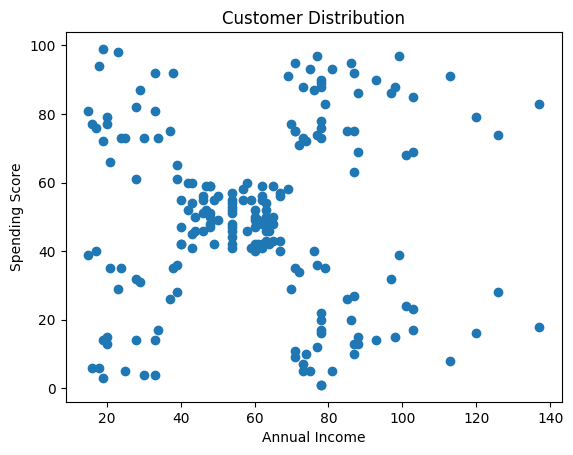

In [16]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Distribution")
plt.show()

#Why did you pick this specific chart?
A scatter plot was selected because it is best suited to visualize the relationship between annual income and spending score. It helps in identifying patterns and potential groupings in the data before applying clustering.
#What are the insights found from the chart?
The chart shows that customers are distributed in different regions based on income and spending behavior. Some visible groupings can be observed, indicating that clustering techniques can be effectively applied to segment customers.

# Elbow Method

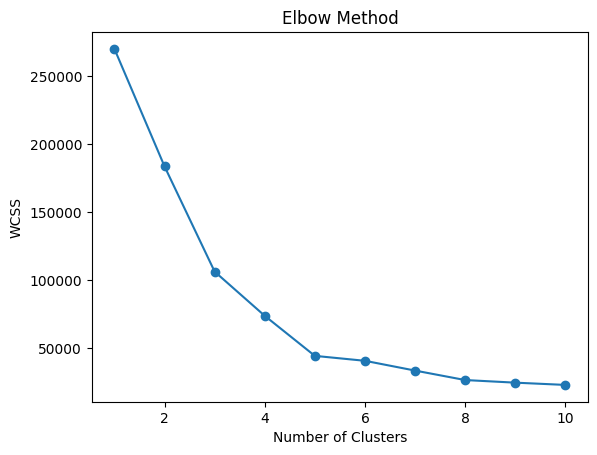

In [21]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

#Why did you pick this specific chart?
The elbow method graph was selected to determine the optimal number of clusters for K-Means clustering. It helps in identifying the point where adding more clusters does not significantly reduce the within-cluster variance.
#What are the insights found from the chart?
The graph shows a clear bend (elbow point), indicating the optimal number of clusters. This suggests that choosing around 5 clusters provides a good balance between accuracy and simplicity for segmenting customers.

# Apply K-Means

In [18]:
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X)

# Final Cluster Visualization

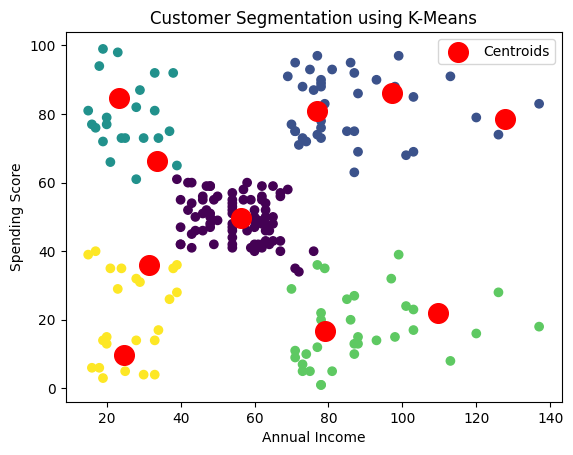

In [33]:
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=y_kmeans, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            s=200, c='red', label='Centroids')

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")
plt.legend()
plt.show()


#Why did you pick this specific chart?
A scatter plot with cluster coloring was selected to visualize the final customer segments created by the K-Means algorithm. It helps in clearly distinguishing different customer groups and their characteristics.
#What are the insights found from the chart?
The chart shows distinct clusters representing different customer segments such as high income-high spending, low income-low spending, and other variations. This indicates that customers can be effectively grouped based on their purchasing behavior.

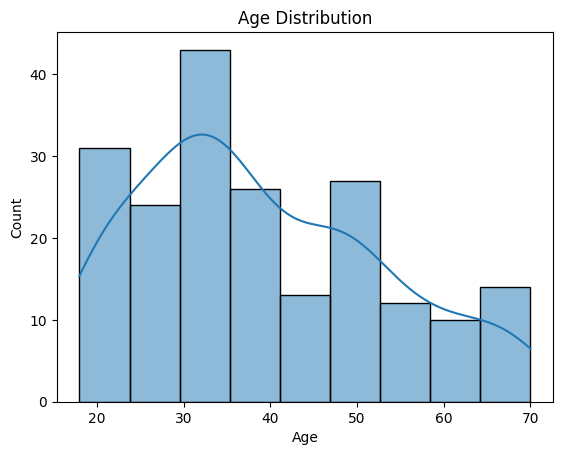

In [24]:
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

#Why did you pick this specific chart?
A histogram was selected to understand how customer ages are distributed.
#What are the insights found from the chart?
The chart shows that most customers belong to the middle-age group.

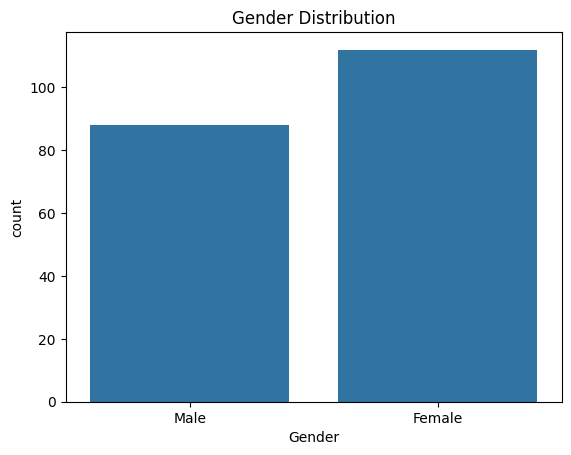

In [25]:
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

#Why did you pick this specific chart?
A count plot helps visualize the distribution of male and female customers.
#What are the insights found from the chart?
The dataset contains both genders with a fairly balanced distribution.

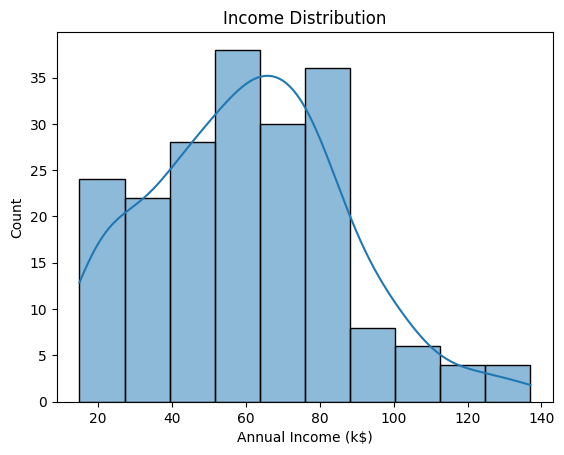

In [26]:
sns.histplot(df['Annual Income (k$)'], kde=True)
plt.title("Income Distribution")
plt.show()

#Why did you pick this specific chart?
To understand how income levels are spread among customers.
#What are the insights found from the chart?
Income values vary significantly, indicating diverse customer groups.

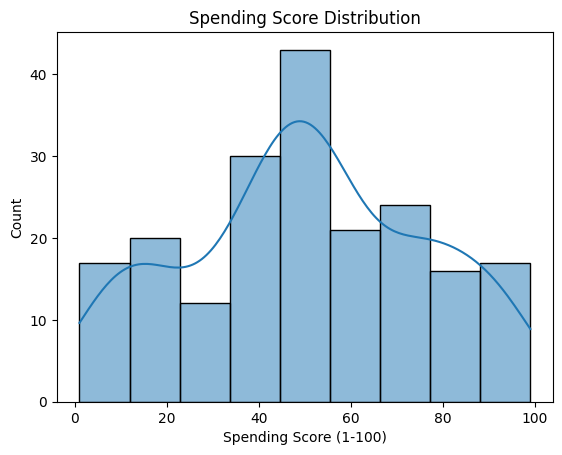

In [27]:
sns.histplot(df['Spending Score (1-100)'], kde=True)
plt.title("Spending Score Distribution")
plt.show()

#Why did you pick this specific chart?
To analyze the variation in customer spending behavior.
#What are the insights found from the chart?
Spending scores are widely distributed, supporting segmentation.

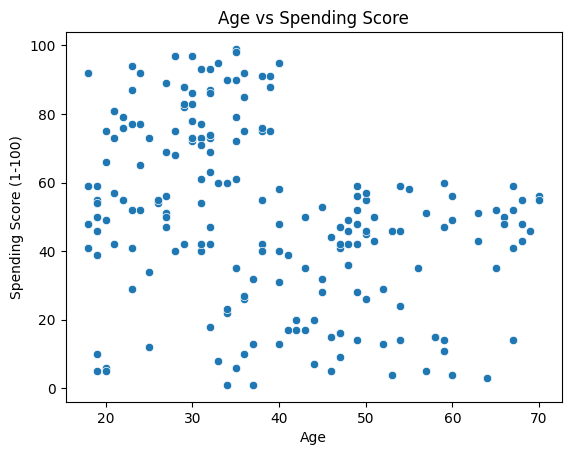

In [28]:
sns.scatterplot(x='Age', y='Spending Score (1-100)', data=df)
plt.title("Age vs Spending Score")
plt.show()

#Why did you pick this specific chart?
To analyze the relationship between age and spending behavior.
#What are the insights found from the chart?
Younger customers tend to have higher spending scores compared to older customers.

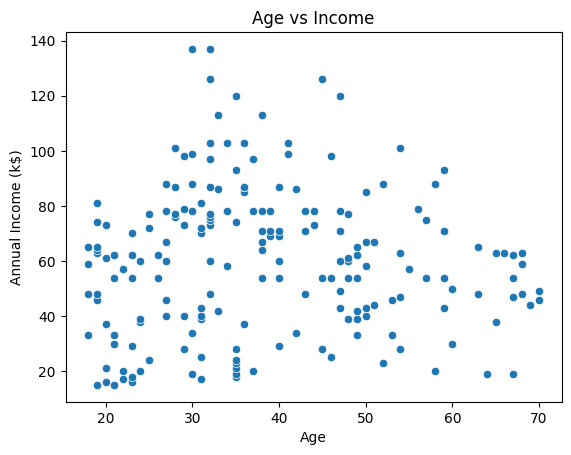

In [29]:
sns.scatterplot(x='Age', y='Annual Income (k$)', data=df)
plt.title("Age vs Income")
plt.show()

#Why did you pick this specific chart?
To observe how income varies across different age groups.
#What are the insights found from the chart?
Income increases with age up to a certain point and then stabilizes.

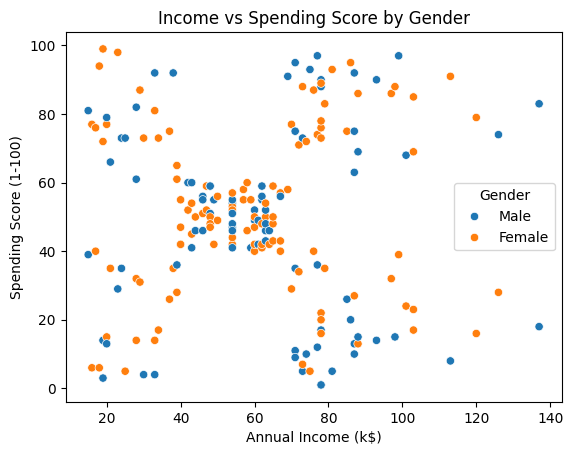

In [31]:
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender', data=df)
plt.title("Income vs Spending Score by Gender")
plt.show()

#Why did you pick this specific chart?
A scatter plot with gender differentiation was selected to analyze how income and spending behavior vary across different customer groups.
#What are the insights found from the chart?
The chart shows how spending patterns differ across income levels and highlights any visible differences between male and female customers. It helps in understanding customer behavior more clearly.

# Conclusion
- Customers are successfully segmented into distinct groups based on income and spending behavior.
- High income and high spending customers represent valuable target segments.
- Customers with high income but low spending indicate potential for targeted marketing.
- Clustering provides meaningful insights that can help businesses improve decision-making and customer targeting.
